# 02 — Data Loading & First Look
Dataset: IBM HR Analytics Employee Attrition  
Goal: load the dataset, explore its structure, and identify the target variable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1470 rows, 35 columns


In [2]:
# First look at the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 👀 First Look

The dataset contains 1,470 employees and 35 features.
Key psychological variables identified:

- **EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction** 
  — multi-dimensional measure of workplace wellbeing
- **WorkLifeBalance** — critical burnout predictor
- **YearsSinceLastPromotion** — career stagnation indicator
- **DistanceFromHome** — logistical stressor

In [3]:
# Dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### 🔍 Dataset Structure

- **No missing values** — dataset is complete (1,470 non-null for all columns)
- **26 numeric features**, 9 categorical features
- **Columns to drop:** `EmployeeCount`, `StandardHours`, `Over18` 
  — zero-variance features that add no predictive value
- **Target variable:** `Attrition` (Yes/No) — what we want to predict

In [4]:
# Check suspicious columns
print(df['EmployeeCount'].value_counts())
print(df['StandardHours'].value_counts())
print(df['Over18'].value_counts())

EmployeeCount
1    1470
Name: count, dtype: int64
StandardHours
80    1470
Name: count, dtype: int64
Over18
Y    1470
Name: count, dtype: int64


In [5]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### 📊 Key Observations

- **Age:** mean 37 years (std 10) — diverse workforce in terms of seniority
- **MonthlyIncome:** mean $6,503 but high std ($4,707) — large salary 
  disparity across employees, potentially linked to burnout risk
- **YearsAtCompany:** mean 7 years (std 6) — high variability in tenure, 
  suggesting different retention patterns across employee groups

In [6]:
# Target variable distribution
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']:.1%}")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


### 🎯 Target Variable: Attrition

- **No (stayed):** ~84% of employees
- **Yes (left):** ~16% of employees

The dataset is **imbalanced** — this means accuracy alone is not 
a reliable metric. We will use F1-Score and recall instead.
This is a common pattern in real HR datasets: attrition is 
relatively rare but extremely costly when it occurs.

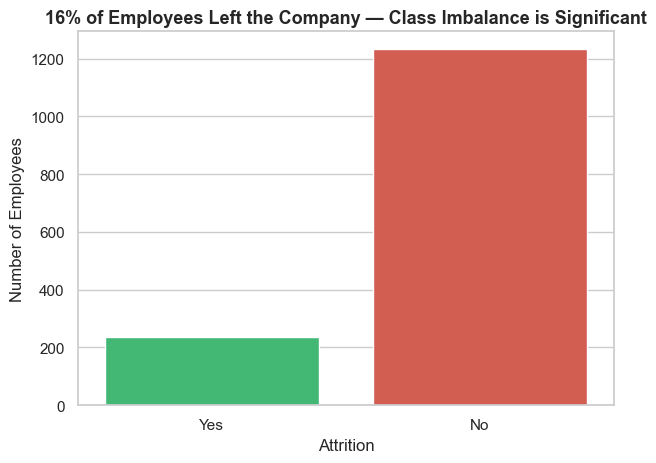

In [7]:
# Attrition distribution plot
fig, ax = plt.subplots()

sns.countplot(data=df, x='Attrition', hue='Attrition',
              palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)

ax.set_title('16% of Employees Left the Company — Class Imbalance is Significant', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Number of Employees')

plt.tight_layout()
plt.savefig('../reports/01_attrition_distribution.png', dpi=150)
plt.show()

### 📊 Attrition Distribution

The chart clearly shows the class imbalance:
- **1,233 employees stayed** (84%)
- **237 employees left** (16%)

This means for every 5 employees, only 1 leaves the company.
While 16% might seem low, in a company of 1,470 people this 
represents a significant cost — potentially millions in 
recruiting and training expenses.

> **Implication for modeling:** accuracy alone will be misleading.
> A model that always predicts "No" would be 84% accurate but 
> completely useless for HR purposes.

In [8]:
# Quick look at attrition by department
df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()

Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


### 🏢 Attrition by Department

| Department | Attrition Rate |
|---|---|
| Sales | 20.6% |
| Human Resources | 19.0% |
| Research & Development | 13.8% |

**Sales** has the highest attrition rate — consistent with 
high-pressure, target-driven environments.

**HR department** showing the second highest rate is particularly 
interesting: those responsible for employee wellbeing may themselves 
be experiencing burnout — a pattern well documented in helping professions.